# Best Models Training Notebook

This notebook preserves the original data-reading and preprocessing flow, then adds a separate best-model training stage. Tuned artifacts are saved under `best_models/<dataset>/` and tracked in `best_models.json`, so the original `models/` cache remains untouched.

In [2]:
%pip install pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import xgboost as xgb
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras import layers
from tabulate import tabulate
from pydantic import BaseModel
from typing import Dict, List
import joblib
import json
import time
import os

MODEL_DIR  = "models"
MODELS_JSON = "models.json"
CICEVSE_SUBDIR = f"{MODEL_DIR}/cicevse"
CICIDS_SUBDIR  = f"{MODEL_DIR}/cicids"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CICEVSE_SUBDIR, exist_ok=True)
os.makedirs(CICIDS_SUBDIR, exist_ok=True)

def _load_registry() -> dict:
    if os.path.exists(MODELS_JSON):
        with open(MODELS_JSON) as f:
            return json.load(f)
    return {}

def _save_registry(registry: dict):
    with open(MODELS_JSON, "w") as f:
        json.dump(registry, f, indent=2)

In [5]:
import shutil

def _migrate_models_to_subdirs():
    """One-time migration: move flat models/* files into models/cicevse/ and update registry."""
    registry = _load_registry()
    if not registry:
        return

    needs_migration = any(
        not entry.get("model_path", "").startswith(f"{CICEVSE_SUBDIR}/")
        for entry in registry.values()
    )
    if not needs_migration:
        return

    new_registry = {}
    for old_key, entry in registry.items():
        old_path = entry["model_path"]
        filename = os.path.basename(old_path)
        new_path = f"{CICEVSE_SUBDIR}/{filename}"

        if os.path.exists(old_path) and not os.path.exists(new_path):
            shutil.move(old_path, new_path)
        elif os.path.exists(old_path) and os.path.exists(new_path):
            os.remove(old_path)

        new_key = f"[CICEVSE] {old_key}" if not old_key.startswith("[") else old_key

        new_entry = dict(entry)
        new_entry["model_path"] = new_path
        new_entry["dataset"] = "cicevse"
        new_registry[new_key] = new_entry

    _save_registry(new_registry)
    print(f"Migrated {len(new_registry)} model(s) to {CICEVSE_SUBDIR}/")

_migrate_models_to_subdirs()

In [6]:
# Configure TensorFlow to use GPU > TPU > CPU (whichever is available)

def configure_tf_device():
    # Suppress verbose TF/CUDA logs before device selection
    os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

    # 1. Try TPU
    try:
        tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
        tf.config.experimental_connect_to_cluster(tpu)
        tf.tpu.experimental.initialize_tpu_system(tpu)
        strategy = tf.distribute.TPUStrategy(tpu)
        print(f"TPU detected — using TPUStrategy ({strategy.num_replicas_in_sync} cores)")
        return strategy, "TPU"
    except (ValueError, tf.errors.NotFoundError):
        pass

    # 2. Try GPU
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            strategy = tf.distribute.MirroredStrategy()
            print(f"GPU detected — using MirroredStrategy ({len(gpus)} GPU(s): "
                  f"{[g.name for g in gpus]})")
            return strategy, "GPU"
        except RuntimeError as e:
            print(f"GPU found but could not be configured: {e}")

    # 3. Fallback to CPU
    strategy = tf.distribute.get_strategy()   # default (no-op) strategy
    print("No GPU/TPU found — falling back to CPU")
    return strategy, "CPU"

tf_strategy, tf_device = configure_tf_device()


No GPU/TPU found — falling back to CPU


In [7]:
class ModelResult(BaseModel):
    model_name: str
    training_time_s: float
    inference_time_ms: float       # per-sample inference latency
    accuracy: float
    precision: float               # weighted
    recall: float                  # weighted
    f1_score: float                # weighted
    accuracy_std: float = 0.0
    precision_std: float = 0.0
    recall_std: float = 0.0
    f1_score_std: float = 0.0
    confusion_matrix: List[List[int]]
    per_class_metrics: Dict[str, Dict[str, float]]  # class label -> {precision, recall, f1-score, support}

    def to_summary_dict(self) -> dict:
        """Flat dict suitable for a summary comparison table row."""
        return {
            'Model':                   self.model_name,
            'Accuracy (%)':            f"{self.accuracy*100:.3f} ± {self.accuracy_std*100:.3f}",
            'Precision (%)':           f"{self.precision*100:.3f} ± {self.precision_std*100:.3f}",
            'Recall (%)':              f"{self.recall*100:.3f} ± {self.recall_std*100:.3f}",
            'F1-Score (%)':            f"{self.f1_score*100:.3f} ± {self.f1_score_std*100:.3f}",
            'Train Time (s)':          round(self.training_time_s,  3),
            'Infer. Time (ms/sample)': round(self.inference_time_ms, 4),
        }

### Load CICEVSE2024 data

In [8]:
# Read the dataset
df_cicevse_2024 = pd.read_csv('CICEVSE2024/Subsets/CICEVSE2024_12classes_kmeans_rule_sampled1000.csv')

In [9]:
df_cicevse_2024

,expiration_id,src_ip,src_mac,src_oui,src_port,dst_ip,dst_mac,dst_oui,dst_port,protocol,...,application_name,application_category_name,application_is_guessed,application_confidence,requested_server_name,client_fingerprint,server_fingerprint,user_agent,content_type,Label
0,0.0,0.396825,0.500000,0.714286,0.135668,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
1,0.0,0.476190,0.500000,0.714286,0.347005,0.453333,0.176471,0.111111,0.001221,0.020408,...,0.230769,1.000000,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
2,0.0,0.317460,0.833333,0.857143,0.703655,0.346667,0.705882,0.777778,0.008286,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,1
3,0.0,0.539683,0.500000,0.714286,0.942000,0.400000,0.705882,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,10
4,0.0,0.396825,0.500000,0.714286,0.152590,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35936,0.0,0.396825,0.500000,0.714286,0.660441,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
35937,0.0,0.539683,0.500000,0.714286,0.929381,0.400000,0.764706,0.777778,0.145495,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,2
35938,0.0,0.317460,0.833333,0.857143,0.690272,0.346667,0.705882,0.777778,0.045853,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,3
35939,0.0,0.539683,0.500000,0.714286,0.799344,0.400000,0.705882,0.777778,0.084077,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,1


In [10]:
# print the class distribution of the last column
df_cicevse_2024['Label'].value_counts()

Label
7     7696
3     5807
1     4739
8     3690
2     3421
5     3110
11    2787
10    1898
9     1577
6     1044
4       90
0       82
Name: count, dtype: int64

| Name                                                   | Original Number of Samples | Reduced Subset | Label |
|--------------------------------------------------------|----------------------------|----------------|-------|
| Class 2 DoS: TCP floods                                | 721044                     | 7696           | 7     |
| Class 1 Discovery: Stealth SYN scanning                | 530946                     | 5807           | 3     |
| Class 1 Discovery: Port scanning                       | 426659                     | 4739           | 1     |
| Class 1 Discovery: Service detection                   | 292856                     | 3690           | 8     |
| Class 2 DoS: Identity rotation and rotation flood      | 262185                     | 3421           | 2    |
| Class 3 Reconnaissance: Vulnerability scan             | 231367                     | 3110           | 5     |
| Class 3 Reconnaissance: OS fingerprinting              | 140273                     | 2787           | 11    |
| Class 3 Reconnaissance: Aggressive scan                | 102522                     | 1898           | 10    |
| Class 2 DoS: UDP flood                                 | 32475                      | 1577           | 9     |
| Class 2 DoS: Slow request starvation                   | 4201                       | 1044           | 6     |
| Class 2 DoS: ICMP flood or fragmentation               | 90                         | 90             | 4     |
| Class 0 Normal                                         | 82                         | 82             | 0     |

C:\Users\100987869\AppData\Local\Temp\ipykernel_35760\3854627974.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha='right')


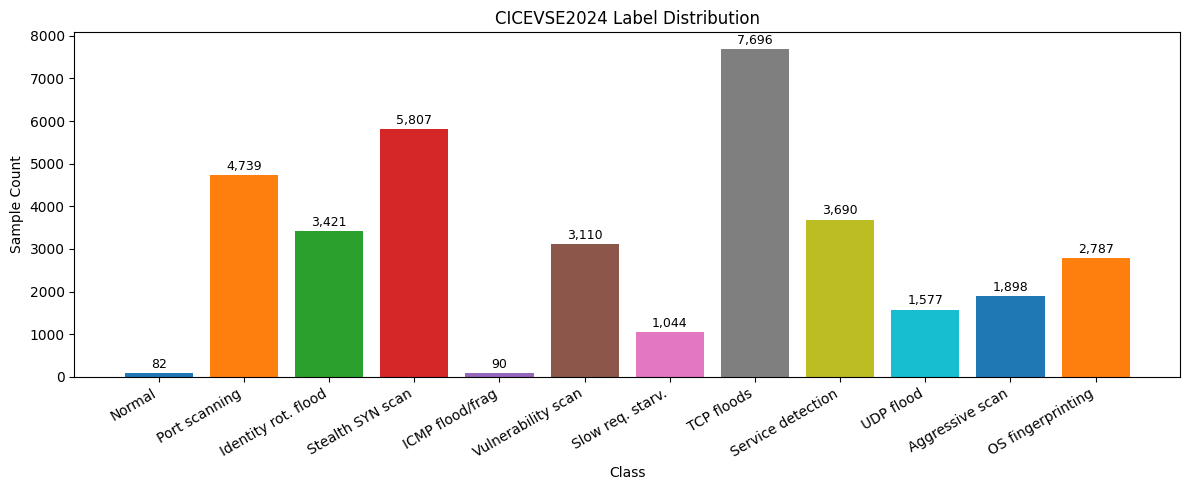

In [11]:
# Bar plot of label value counts with class names
label_names_cicevse = {
    0: 'Normal',
    1: 'Port scanning',
    2: 'Identity rot. flood',
    3: 'Stealth SYN scan',
    4: 'ICMP flood/frag',
    5: 'Vulnerability scan',
    6: 'Slow req. starv.',
    7: 'TCP floods',
    8: 'Service detection',
    9: 'UDP flood',
    10: 'Aggressive scan',
    11: 'OS fingerprinting',
}

counts = df_cicevse_2024['Label'].value_counts().sort_index()
labels = [label_names_cicevse[i] for i in counts.index]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, counts.values, color=sns.color_palette('tab10', len(counts)))
ax.set_xlabel('Class')
ax.set_ylabel('Sample Count')
ax.set_title('CICEVSE2024 Label Distribution')
ax.set_xticklabels(labels, rotation=30, ha='right')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Load CICIDS2017 data

In [12]:
# Read the CICIDS2017 dataset
df_cicids_2017 = pd.read_csv(r'c:\Users\100987869\Downloads\cic_0.01km.csv')

In [13]:
df_cicids_2017

,Flow Duration,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Mean,Bwd Packet Length Max,Bwd Packet Length Min,Flow IAT Mean,Flow IAT Min,Fwd IAT Min,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,URG Flag Count,Down/Up Ratio,Init_Win_bytes_forward,Init_Win_bytes_backward,min_seg_size_forward,Label
0,50833,0,0,0.0000,0,0,5.083300e+04,50833,0,32,32,19.672260,19.672260,0,1,1,319,153,32,0
1,49,0,0,0.0000,0,0,4.900000e+01,49,49,64,0,40816.326530,0.000000,0,0,0,277,-1,32,0
2,306,6,6,6.0000,6,6,3.060000e+02,306,0,20,20,3267.973856,3267.973856,6,0,1,0,0,20,0
3,63041,65,65,65.0000,124,124,6.304100e+04,63041,0,32,32,15.862693,15.862693,65,0,1,-1,-1,32,0
4,47682,43,43,43.0000,59,59,4.768200e+04,47682,0,32,32,20.972275,20.972275,43,0,1,-1,-1,32,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28298,45,0,0,0.0000,0,0,4.500000e+01,45,0,32,32,22222.222220,22222.222220,0,1,1,349,307,32,0
28299,114309573,511,427,31.9375,746,0,3.941709e+06,94,165,332,424,0.139971,0.122474,0,0,0,8192,343,20,0
28300,48850,80,40,40.0000,72,72,1.628333e+04,1,48,64,64,40.941658,40.941658,40,0,1,-1,-1,32,0
28301,260,66,33,33.0000,97,97,8.666667e+01,48,48,40,40,7692.307692,7692.307692,33,0,1,-1,-1,20,0


In [14]:
# print the class distribution of the last column
df_cicids_2017['Label'].value_counts()

Label
0    22662
1     5641
Name: count, dtype: int64

C:\Users\100987869\AppData\Local\Temp\ipykernel_35760\2388737226.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha='right')


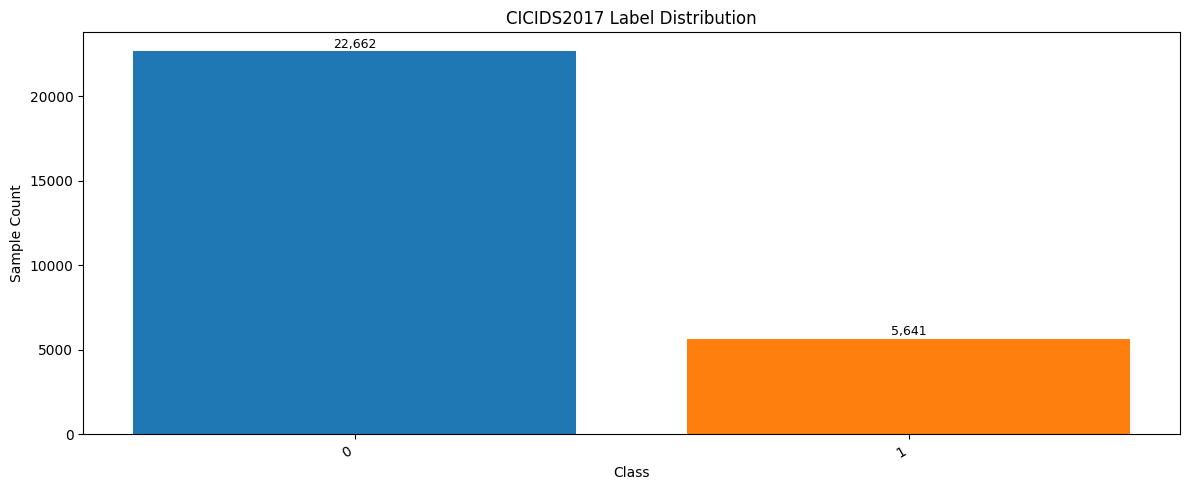

In [15]:
counts = df_cicids_2017['Label'].value_counts()
labels = [str(l) for l in counts.index]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, counts.values, color=sns.color_palette('tab10', len(counts)))
ax.set_xlabel('Class')
ax.set_ylabel('Sample Count')
ax.set_title('CICIDS2017 Label Distribution')
ax.set_xticklabels(labels, rotation=30, ha='right')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Load NF-Ton-IoT-V2 data

In [16]:
# Read the NF-ToN-IoT-V2 dataset
df_nfton = pd.read_parquet('NF-Ton-IoT-V2/NF-ToN-IoT-V2.parquet')
df_nfton

,L4_SRC_PORT,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,...,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label,Attack
0,49235,4444,6,0.000000,155392,202,34552,149,24,24,...,45555,4805,0,0,0,0,0,0,1,ransomware
1,49228,1880,6,0.000000,1600,40,35741,65,24,16,...,16425,237,0,0,0,0,0,0,0,Benign
2,0,0,1,0.000000,212,2,0,0,0,0,...,0,0,771,3,0,0,0,0,0,Benign
3,65317,1900,17,0.000000,165,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Benign
4,60766,15600,17,0.000000,63,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13135876,49200,4444,6,0.000000,152960,210,36392,163,24,24,...,16425,2385,0,0,0,0,0,0,1,ransomware
13135877,1880,49178,6,0.000000,31067,49,1160,29,24,24,...,237,16425,0,0,0,0,0,0,0,Benign
13135878,43,37796,6,170.000000,4275,5,296,5,25,25,...,453,1024,19200,75,0,0,0,0,0,Benign
13135879,443,49198,6,91.178001,191,4,151,3,25,25,...,64240,63846,0,0,0,0,0,0,0,Benign


In [17]:
print("NF-ToN-IoT-V2 shape:", df_nfton.shape)
# check the last few columns and label candidate
print(df_nfton.columns[-5:])
print("Last column:", df_nfton.columns[-1])

NF-ToN-IoT-V2 shape: (13135881, 43)
Index(['DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE', 'Label',
       'Attack'],
      dtype='str')
Last column: Attack


In [18]:
# select label column
possible_label_cols = ['Label', 'label', 'Attack', 'attack', 'Category', 'category', 'Target', 'target', 'Description']

label_col_nfton = None
for col in possible_label_cols:
    if col in df_nfton.columns:
        label_col_nfton = col
        break

if label_col_nfton is None:
    label_col_nfton = df_nfton.columns[-1]

print("Selected label column:", label_col_nfton)

Selected label column: Label


In [19]:
# drop raw IP address columns
for col in ['IPV4_SRC_ADDR', 'IPV4_DST_ADDR']:
    if col in df_nfton.columns:
        df_nfton.drop(columns=[col], inplace=True)

### Data pre-processing (NF-ToN-IoT-V2)

In [20]:
# Encode the dataset
labelencoder_nfton = LabelEncoder()
df_nfton[label_col_nfton] = labelencoder_nfton.fit_transform(df_nfton[label_col_nfton].astype(str))

In [21]:
# drop non-numeric feature columns
non_numeric_cols = df_nfton.drop(columns=[label_col_nfton]).select_dtypes(exclude=[np.number]).columns.tolist()

if non_numeric_cols:
    print("Dropping non-numeric columns:", non_numeric_cols)
    df_nfton.drop(columns=non_numeric_cols, inplace=True)

Dropping non-numeric columns: ['Attack']


In [22]:
# min-max normalization
for column in df_nfton.drop(columns=[label_col_nfton]).columns:
    col_min = df_nfton[column].min()
    col_max = df_nfton[column].max()

    if col_max != col_min:
        df_nfton[column] = (df_nfton[column] - col_min) / (col_max - col_min)
    else:
        df_nfton[column] = 0

In [23]:
# address empty values
if df_nfton.isnull().values.any() or np.isinf(df_nfton.select_dtypes(include=[np.number])).values.any():
    df_nfton.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_nfton.fillna(0, inplace=True)

In [24]:
X_nfton = df_nfton.drop(columns=[label_col_nfton])
y_nfton = df_nfton[label_col_nfton]

# 3-fold stratified cross-validation
cv_nfton = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [25]:

# stratified subset for practical benchmarking
X_nfton_sub, _, y_nfton_sub, _ = train_test_split(
    X_nfton,
    y_nfton,
    train_size=50000,   # s
    stratify=y_nfton,
    random_state=42
)

cv_nfton = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Original NFToN shape:", X_nfton.shape)
print("Subset NFToN shape:", X_nfton_sub.shape)
print("Class distribution in subset:")
print(pd.Series(y_nfton_sub).value_counts(normalize=True))

Original NFToN shape: (13135881, 41)
Subset NFToN shape: (50000, 41)
Class distribution in subset:
Label
1    0.72584
0    0.27416
Name: proportion, dtype: float64


In [26]:
#saving directory for NF-ToN models
NFToN_SUBDIR = f"{MODEL_DIR}/nfton"
os.makedirs(NFToN_SUBDIR, exist_ok=True)

### Data pre-processing (CICEVSE2024)

In [27]:
# Encode the dataset
labelencoder = LabelEncoder()
df_cicevse_2024.iloc[:, -1] = labelencoder.fit_transform(df_cicevse_2024.iloc[:, -1])

In [28]:
# min-max normalization
for column in df_cicevse_2024.columns[:-1]: # excluding the last column
    df_cicevse_2024[column] = (df_cicevse_2024[column] - df_cicevse_2024[column].min()) / (df_cicevse_2024[column].max() - df_cicevse_2024[column].min())

In [29]:
# address empty values
if df_cicevse_2024.isnull().values.any() or np.isinf(df_cicevse_2024).values.any():
    df_cicevse_2024.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_cicevse_2024.fillna(0, inplace=True)

In [30]:
X_cicevse = df_cicevse_2024.drop(['Label'], axis=1)
y_cicevse = df_cicevse_2024.iloc[:, -1]

# 3-fold stratified cross-validation
cv_cicevse = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

### Data pre-processing (CICIDS2017)

In [31]:
# Encode string labels to integers
labelencoder_cicids = LabelEncoder()
df_cicids_2017['Label'] = labelencoder_cicids.fit_transform(df_cicids_2017['Label'])

In [32]:
# min-max normalization
for column in df_cicids_2017.columns[:-1]:
    col_range = df_cicids_2017[column].max() - df_cicids_2017[column].min()
    if col_range > 0:
        df_cicids_2017[column] = (df_cicids_2017[column] - df_cicids_2017[column].min()) / col_range
    else:
        df_cicids_2017[column] = 0

In [33]:
# address empty values
if df_cicids_2017.isnull().values.any() or np.isinf(df_cicids_2017.select_dtypes(include=[np.number])).values.any():
    df_cicids_2017.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_cicids_2017.fillna(0, inplace=True)

In [34]:
X_cicids = df_cicids_2017.drop(['Label'], axis=1)
y_cicids = df_cicids_2017['Label']

# 3-fold stratified cross-validation
cv_cicids = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


In [35]:
print("CICEVSE first 10 cols:", list(X_cicevse.columns[:10]))
print("CICEVSE shape:", X_cicevse.shape)

print("CICIDS first 10 cols:", list(X_cicids.columns[:10]))
print("CICIDS shape:", X_cicids.shape)

print("NFToN first 10 cols:", list(X_nfton.columns[:10]))
print("NFToN shape:", X_nfton.shape)

CICEVSE first 10 cols: ['expiration_id', 'src_ip', 'src_mac', 'src_oui', 'src_port', 'dst_ip', 'dst_mac', 'dst_oui', 'dst_port', 'protocol']
CICEVSE shape: (35941, 85)
CICIDS first 10 cols: ['Flow Duration', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Flow IAT Mean', 'Flow IAT Min', 'Fwd IAT Min', 'Fwd Header Length']
CICIDS shape: (28303, 19)
NFToN first 10 cols: ['L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS']
NFToN shape: (13135881, 41)


### Reference Models from Literature

| Paper | Link | Models |
|-------|------|--------|
| Tree-based Intelligent Intrusion Detection System in Internet of Vehicles | [arXiv:1910.08635](https://arxiv.org/pdf/1910.08635) | Random Forest, Decision Tree, Extra Tree, XGBoost |
| MTH-IDS: A Multitiered Hybrid Intrusion Detection System for Internet of Vehicles | [IEEE Xplore](https://ieeexplore-ieee-org.uproxy.library.dc-uoit.ca/document/9443234) | Multi-SVM, KNN |
|A Transfer Learning and Optimized CNN Based Intrusion Detection System for Internet of Vehicles| [IEEE Xplore](https://ieeexplore-ieee-org.uproxy.library.dc-uoit.ca/document/9838780) | VGG16, VGG19|
|Deep Learning Approach for Intelligent Intrusion Detection System| [IEEE Xplore](https://ieeexplore.ieee.org/abstract/document/8681044)| DNN, LR|
| | | LightGBM|


## Best-model output paths and registry

In [36]:

BEST_MODEL_DIR = "best_models"
BEST_MODELS_JSON = "best_models.json"

BEST_CICEVSE_SUBDIR = f"{BEST_MODEL_DIR}/cicevse"
BEST_CICIDS_SUBDIR  = f"{BEST_MODEL_DIR}/cicids"
BEST_NFTON_SUBDIR   = f"{BEST_MODEL_DIR}/nfton"

for _p in [BEST_MODEL_DIR, BEST_CICEVSE_SUBDIR, BEST_CICIDS_SUBDIR, BEST_NFTON_SUBDIR]:
    os.makedirs(_p, exist_ok=True)

def _load_best_registry() -> dict:
    if os.path.exists(BEST_MODELS_JSON):
        with open(BEST_MODELS_JSON) as f:
            return json.load(f)
    return {}

def _save_best_registry(registry: dict):
    with open(BEST_MODELS_JSON, "w") as f:
        json.dump(registry, f, indent=2)

from sklearn.metrics import f1_score
from sklearn.model_selection import ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import itertools

# ---------------------------------------------------------------------
# Best-model execution controls
# ---------------------------------------------------------------------
# cache_or_train: use saved CV metrics when available, train missing models only
# cache_only:     never train; fail clearly if a result cache is missing
# force_train:    ignore saved CV metrics and retrain
BEST_RUN_MODE = "cache_or_train"

# Optional filters for fast debugging.
# Examples:
# BEST_MODEL_FILTER = ["XGBoost", "Random Forest"]
# FAST_DEV_MAX_MODELS_PER_DATASET = 2
BEST_MODEL_FILTER = None
FAST_DEV_MAX_MODELS_PER_DATASET = None


def _result_cache_path(model_path: str) -> str:
    return f"{model_path}.cv_result.json"


def _model_result_to_dict(result: ModelResult) -> dict:
    if hasattr(result, "model_dump"):
        return result.model_dump()
    return result.dict()


def _save_result_cache(model_path: str, result: ModelResult, extra: dict | None = None):
    payload = _model_result_to_dict(result)
    payload["_cache_note"] = (
        "Cross-validation metrics from fold-held-out evaluation. "
        "Do not recompute these metrics by evaluating the final full-data model."
    )
    if extra:
        payload["_extra"] = extra
    with open(_result_cache_path(model_path), "w") as f:
        json.dump(payload, f, indent=2)


def _load_result_cache(model_path: str, model_name: str | None = None):
    cache_path = _result_cache_path(model_path)
    if not os.path.exists(cache_path):
        return None
    with open(cache_path) as f:
        payload = json.load(f)
    payload.pop("_cache_note", None)
    payload.pop("_extra", None)
    result = ModelResult(**payload)
    if model_name is not None and result.model_name != model_name:
        print(f"Warning: cached result model name differs: {result.model_name} != {model_name}")
    return result


def _should_run_model(label: str) -> bool:
    if BEST_MODEL_FILTER is None:
        return True
    return any(key.lower() in label.lower() for key in BEST_MODEL_FILTER)


## Shared helpers

In [37]:

def _per_class_from_conf_matrix(conf_matrix, labels):
    per_class = {}
    for i, lbl in enumerate(labels):
        tp = conf_matrix[i, i]
        fp = conf_matrix[:, i].sum() - tp
        fn = conf_matrix[i, :].sum() - tp
        support = conf_matrix[i, :].sum()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        per_class[str(lbl)] = {"precision": prec, "recall": rec, "f1-score": f1, "support": float(support)}
    return per_class


def _finalize_result(model_name, total_train_time, total_infer_time, total_test_samples,
                     fold_acc, fold_prec, fold_rec, fold_f1, fold_conf, all_labels):
    return ModelResult(
        model_name=model_name,
        training_time_s=float(total_train_time),
        inference_time_ms=float(total_infer_time / max(total_test_samples, 1) * 1000.0),
        accuracy=float(np.mean(fold_acc)),
        precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)),
        f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)),
        precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)),
        f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


def _evaluate_predictions(y_true, y_pred, fold_acc, fold_prec, fold_rec, fold_f1, fold_conf, all_labels):
    fold_acc.append(accuracy_score(y_true, y_pred))
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    fold_prec.append(p)
    fold_rec.append(r)
    fold_f1.append(f)
    cm = confusion_matrix(y_true, y_pred, labels=all_labels)
    fold_conf = cm if fold_conf is None else (fold_conf + cm)
    return fold_conf


def _sample_params(param_grid, n_iter=12, random_state=42):
    if not param_grid:
        return [dict()]
    sampled = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=random_state))
    unique = []
    seen = set()
    for params in sampled:
        key = tuple(sorted(params.items()))
        if key not in seen:
            seen.add(key)
            unique.append(params)
    return unique


def _prepare_flat(X):
    return X.values.astype(np.float32)


def _prepare_conv1d(X):
    arr = X.values.astype(np.float32)
    return arr.reshape(-1, arr.shape[1], 1)


def _make_lstm_prepare_fn(n_features, chunk_size=5):
    remainder = n_features % chunk_size
    pad_width = 0 if remainder == 0 else (chunk_size - remainder)
    timesteps = (n_features + pad_width) // chunk_size

    def _prepare(X):
        arr = X.values.astype(np.float32)
        if pad_width > 0:
            arr = np.concatenate([arr, np.zeros((arr.shape[0], pad_width), dtype=np.float32)], axis=1)
        return arr.reshape((arr.shape[0], timesteps, chunk_size))
    return _prepare


## Hyperparameter tuning for classical and tree-based models

In [38]:

def train_sklearn_tuned(
    X, y, cv, model_name, model_path, estimator_factory, param_grid,
    n_iter=12, inner_cv=3
):
    registry = _load_best_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    total_train_time = 0.0
    all_labels = sorted(np.unique(y))

    # Never evaluate the final full-data saved model as if it were a CV fold model.
    # That causes leakage and can create artificial 100% reload scores.
    if BEST_RUN_MODE != "force_train":
        cached_result = _load_result_cache(model_path, model_name=model_name)
        if cached_result is not None:
            print(f"Loading cached CV result for {model_name} from {_result_cache_path(model_path)}")
            return cached_result

    if BEST_RUN_MODE == "cache_only":
        raise FileNotFoundError(
            f"Missing CV result cache for {model_name}: {_result_cache_path(model_path)}. "
            "Run once with BEST_RUN_MODE='cache_or_train' or 'force_train'."
        )

    for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        print(f"  Fold {fold_i}: Tuning {model_name}...")
        start = time.time()
        search = RandomizedSearchCV(
            estimator=estimator_factory(),
            param_distributions=param_grid,
            n_iter=n_iter,
            scoring='f1_weighted',
            cv=inner_cv,
            n_jobs=-1,
            random_state=42,
            refit=True,
        )
        search.fit(X_train, y_train)
        total_train_time += time.time() - start
        model = search.best_estimator_

        start = time.time()
        y_pred = model.predict(X_test)
        total_infer_time += time.time() - start
        total_test_samples += len(X_test)
        fold_conf = _evaluate_predictions(y_test, y_pred, fold_acc, fold_prec, fold_rec, fold_f1, fold_conf, all_labels)
        print(f"  Fold {fold_i}: Best params={search.best_params_}")
        print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

    print(f"Training final tuned {model_name} on full dataset...")
    final_search = RandomizedSearchCV(
        estimator=estimator_factory(),
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring='f1_weighted',
        cv=inner_cv,
        n_jobs=-1,
        random_state=42,
        refit=True,
    )
    final_search.fit(X, y)
    final_model = final_search.best_estimator_
    joblib.dump(final_model, model_path)

    registry[model_name] = {
        "training_time": total_train_time,
        "model_path": model_path,
        "best_params": final_search.best_params_,
    }
    _save_best_registry(registry)

    result = _finalize_result(model_name, total_train_time, total_infer_time, total_test_samples,
                              fold_acc, fold_prec, fold_rec, fold_f1, fold_conf, all_labels)
    _save_result_cache(model_path, result, extra={"best_params": final_search.best_params_})
    return result


def train_xgboost_best(X, y, cv, model_name, model_path):
    n_classes = len(np.unique(y))
    param_grid = {
        "n_estimators": [150, 250, 400],
        "max_depth": [4, 6, 8, 10],
        "learning_rate": [0.03, 0.05, 0.1],
        "subsample": [0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
        "min_child_weight": [1, 3, 5],
        "gamma": [0.0, 0.1, 0.3],
    }
    def factory():
        kwargs = dict(
            random_state=42,
            tree_method="hist",
            eval_metric="mlogloss",
        )
        if n_classes > 2:
            kwargs["objective"] = "multi:softprob"
            kwargs["num_class"] = n_classes
        else:
            kwargs["objective"] = "binary:logistic"
        return xgb.XGBClassifier(**kwargs)
    return train_sklearn_tuned(X, y, cv, model_name, model_path, factory, param_grid, n_iter=12)


def train_random_forest_best(X, y, cv, model_name, model_path):
    param_grid = {
        "n_estimators": [200, 400, 600],
        "max_depth": [None, 15, 25, 40],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", 0.5],
        "bootstrap": [True, False],
    }
    return train_sklearn_tuned(X, y, cv, model_name, model_path,
                               lambda: RandomForestClassifier(random_state=42, n_jobs=-1),
                               param_grid, n_iter=12)


def train_decision_tree_best(X, y, cv, model_name, model_path):
    param_grid = {
        "criterion": ["gini", "entropy", "log_loss"],
        "max_depth": [None, 10, 20, 30, 50],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 4, 8],
        "max_features": [None, "sqrt", "log2"],
        "ccp_alpha": [0.0, 0.0001, 0.001, 0.01],
    }
    return train_sklearn_tuned(X, y, cv, model_name, model_path,
                               lambda: DecisionTreeClassifier(random_state=42),
                               param_grid, n_iter=12)


def train_extra_trees_best(X, y, cv, model_name, model_path):
    param_grid = {
        "n_estimators": [200, 400, 600],
        "max_depth": [None, 15, 25, 40],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", 0.5],
        "bootstrap": [False, True],
    }
    return train_sklearn_tuned(X, y, cv, model_name, model_path,
                               lambda: ExtraTreesClassifier(random_state=42, n_jobs=-1),
                               param_grid, n_iter=12)


def train_svm_best(X, y, cv, model_name, model_path):
    param_grid = {
        "model__C": [0.1, 1, 10, 30],
        "model__kernel": ["rbf", "poly"],
        "model__gamma": ["scale", "auto", 0.01, 0.001],
        "model__degree": [2, 3],
    }
    return train_sklearn_tuned(
        X, y, cv, model_name, model_path,
        lambda: Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC())
        ]),
        param_grid, n_iter=10
    )


def train_knn_best(X, y, cv, model_name, model_path):
    param_grid = {
        "model__n_neighbors": [3, 5, 7, 9, 11, 15],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["minkowski"],
        "model__p": [1, 2],
    }
    return train_sklearn_tuned(
        X, y, cv, model_name, model_path,
        lambda: Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        param_grid, n_iter=12
    )


def train_logistic_regression_best(X, y, cv, model_name, model_path):
    param_grid = {
        "model__C": [0.01, 0.1, 1.0, 5.0, 10.0],
        "model__solver": ["lbfgs", "newton-cg", "saga"],
        "model__penalty": ["l2"],
        "model__max_iter": [1000, 2000],
    }
    return train_sklearn_tuned(
        X, y, cv, model_name, model_path,
        lambda: Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(random_state=42))
        ]),
        param_grid, n_iter=10
    )


def train_lightgbm_best(X, y, cv, model_name, model_path):
    param_grid = {
        "n_estimators": [150, 250, 400],
        "learning_rate": [0.03, 0.05, 0.1],
        "num_leaves": [15, 31, 63],
        "max_depth": [6, 10, -1],
        "min_child_samples": [10, 20, 40],
        "subsample": [0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
        "reg_alpha": [0.0, 0.1, 1.0],
        "reg_lambda": [0.0, 0.1, 1.0],
    }
    return train_sklearn_tuned(X, y, cv, model_name, model_path,
                               lambda: lgb.LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1),
                               param_grid, n_iter=15)


## Hyperparameter tuning for deep models

In [39]:

def _keras_trial_list(trial_space):
    keys = list(trial_space.keys())
    trials = []
    for combo in itertools.product(*[trial_space[k] for k in keys]):
        trials.append(dict(zip(keys, combo)))
    return trials


def _fit_and_score_keras_trial(build_fn, X_train_ready, y_train, trial_cfg):
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_ready, y_train,
        test_size=0.1,
        stratify=y_train,
        random_state=42
    )
    tf.keras.backend.clear_session()
    with tf_strategy.scope():
        model = build_fn(trial_cfg)
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
    start = time.time()
    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=trial_cfg.get("epochs", 40),
        batch_size=trial_cfg.get("batch_size", 256),
        verbose=0,
        callbacks=callbacks,
    )
    train_time = time.time() - start
    probs = model.predict(X_val, verbose=0)
    y_pred = np.argmax(probs, axis=1)
    score = f1_score(y_val, y_pred, average="weighted", zero_division=0)
    return score, train_time, model


def train_keras_tuned(X, y, cv, model_name, model_path, build_fn, prepare_fn, trial_space):
    registry = _load_best_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    total_train_time = 0.0
    all_labels = sorted(np.unique(y))
    trials = _keras_trial_list(trial_space)

    # Never evaluate the final full-data saved model as if it were a CV fold model.
    # That causes leakage and can create artificial reload scores.
    if BEST_RUN_MODE != "force_train":
        cached_result = _load_result_cache(model_path, model_name=model_name)
        if cached_result is not None:
            print(f"Loading cached CV result for {model_name} from {_result_cache_path(model_path)}")
            return cached_result

    if BEST_RUN_MODE == "cache_only":
        raise FileNotFoundError(
            f"Missing CV result cache for {model_name}: {_result_cache_path(model_path)}. "
            "Run once with BEST_RUN_MODE='cache_or_train' or 'force_train'."
        )

    best_global_cfg = None
    best_global_score = -1.0

    for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        X_tr = prepare_fn(X_train)
        X_te = prepare_fn(X_test)

        print(f"  Fold {fold_i}: Tuning {model_name}...")
        best_fold_score = -1.0
        best_fold_cfg = None
        best_fold_model = None
        best_fold_train_time = 0.0

        for trial_cfg in trials:
            score, train_time, trial_model = _fit_and_score_keras_trial(build_fn, X_tr, y_train.values, trial_cfg)
            if score > best_fold_score:
                best_fold_score = score
                best_fold_cfg = dict(trial_cfg)
                best_fold_model = trial_model
                best_fold_train_time = train_time

        total_train_time += best_fold_train_time
        start = time.time()
        probs = best_fold_model.predict(X_te, verbose=0)
        total_infer_time += time.time() - start
        total_test_samples += len(X_test)
        y_pred = np.argmax(probs, axis=1)
        fold_conf = _evaluate_predictions(y_test, y_pred, fold_acc, fold_prec, fold_rec, fold_f1, fold_conf, all_labels)

        print(f"  Fold {fold_i}: Best config={best_fold_cfg}")
        print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        if best_fold_score > best_global_score:
            best_global_score = best_fold_score
            best_global_cfg = dict(best_fold_cfg)

    print(f"Training final tuned {model_name} on full dataset...")
    X_full = prepare_fn(X)
    tf.keras.backend.clear_session()
    with tf_strategy.scope():
        final_model = build_fn(best_global_cfg)
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
    final_model.fit(
        X_full, y.values,
        validation_split=0.1,
        epochs=best_global_cfg.get("epochs", 40),
        batch_size=best_global_cfg.get("batch_size", 256),
        verbose=0,
        callbacks=callbacks,
    )
    final_model.save(model_path)

    registry[model_name] = {
        "training_time": total_train_time,
        "model_path": model_path,
        "best_params": best_global_cfg,
    }
    _save_best_registry(registry)

    result = _finalize_result(model_name, total_train_time, total_infer_time, total_test_samples,
                              fold_acc, fold_prec, fold_rec, fold_f1, fold_conf, all_labels)
    _save_result_cache(model_path, result, extra={"best_params": best_global_cfg})
    return result


def build_dnn_model(n_features, n_classes, cfg):
    dropout = cfg.get("dropout", 0.3)
    dense_scale = cfg.get("dense_scale", 1.0)
    lr = cfg.get("learning_rate", 1e-3)

    def scaled(v):
        return max(32, int(v * dense_scale))

    inp = tf.keras.Input(shape=(n_features,))
    x = layers.Dense(scaled(1024), activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(scaled(768), activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(scaled(512), activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(scaled(256), activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(scaled(128), activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    model = tf.keras.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def _vgg_block_1d(x, filters, n_convs):
    for _ in range(n_convs):
        x = layers.Conv1D(filters, 3, padding='same', activation='relu')(x)
    seq_len = x.shape[1]
    if seq_len is None or seq_len >= 2:
        x = layers.MaxPooling1D(pool_size=2, padding='same')(x)
    return x


def build_vgg16_model(n_features, n_classes, cfg):
    dropout = cfg.get("dropout", 0.5)
    lr = cfg.get("learning_rate", 1e-3)
    dense_units = cfg.get("dense_units", 1024)
    inp = tf.keras.Input(shape=(n_features, 1))
    x = _vgg_block_1d(inp, 64, 2)
    x = _vgg_block_1d(x, 128, 2)
    x = _vgg_block_1d(x, 256, 3)
    x = _vgg_block_1d(x, 512, 3)
    x = _vgg_block_1d(x, 512, 3)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    model = tf.keras.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def build_vgg19_model(n_features, n_classes, cfg):
    dropout = cfg.get("dropout", 0.5)
    lr = cfg.get("learning_rate", 1e-3)
    dense_units = cfg.get("dense_units", 1024)
    inp = tf.keras.Input(shape=(n_features, 1))
    x = _vgg_block_1d(inp, 64, 2)
    x = _vgg_block_1d(x, 128, 2)
    x = _vgg_block_1d(x, 256, 4)
    x = _vgg_block_1d(x, 512, 4)
    x = _vgg_block_1d(x, 512, 4)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    model = tf.keras.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def build_cnn_model(n_features, n_classes, cfg):
    dropout = cfg.get("dropout", 0.3)
    lr = cfg.get("learning_rate", 1e-3)
    dense_units = cfg.get("dense_units", 256)
    inp = tf.keras.Input(shape=(n_features, 1))
    x = layers.Conv1D(64, 5, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2, padding='same')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2, padding='same')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(max(64, dense_units // 2), activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    model = tf.keras.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def build_lstm_model(n_features, n_classes, cfg):
    lr = cfg.get("learning_rate", 1e-3)
    proj_units = cfg.get("proj_units", 32)
    lstm_units = cfg.get("lstm_units", 64)
    dense_units = cfg.get("dense_units", 64)
    dropout = cfg.get("dropout", 0.2)
    prepare_fn = _make_lstm_prepare_fn(n_features, chunk_size=5)
    sample_shape = prepare_fn(pd.DataFrame(np.zeros((1, n_features), dtype=np.float32))).shape[1:]
    inp = tf.keras.Input(shape=sample_shape)
    x = layers.Dense(proj_units, activation='relu')(inp)
    x = layers.LSTM(lstm_units, dropout=dropout, recurrent_dropout=0.0)(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    model = tf.keras.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def train_dnn_best(X, y, cv, model_name, model_path):
    n_features = X.shape[1]
    n_classes = len(np.unique(y))
    trial_space = {
        "learning_rate": [1e-3, 5e-4],
        "dropout": [0.2, 0.3, 0.5],
        "dense_scale": [0.75, 1.0],
        "batch_size": [128, 256],
        "epochs": [40, 60],
    }
    return train_keras_tuned(X, y, cv, model_name, model_path,
                             lambda cfg: build_dnn_model(n_features, n_classes, cfg),
                             _prepare_flat, trial_space)


def train_vgg16_best(X, y, cv, model_name, model_path):
    n_features = X.shape[1]
    n_classes = len(np.unique(y))
    trial_space = {
        "learning_rate": [1e-3, 5e-4],
        "dropout": [0.3, 0.5],
        "dense_units": [512, 1024],
        "batch_size": [256, 512],
        "epochs": [30, 50],
    }
    return train_keras_tuned(X, y, cv, model_name, model_path,
                             lambda cfg: build_vgg16_model(n_features, n_classes, cfg),
                             _prepare_conv1d, trial_space)


def train_vgg19_best(X, y, cv, model_name, model_path):
    n_features = X.shape[1]
    n_classes = len(np.unique(y))
    trial_space = {
        "learning_rate": [1e-3, 5e-4],
        "dropout": [0.3, 0.5],
        "dense_units": [512, 1024],
        "batch_size": [128, 256],
        "epochs": [30, 50],
    }
    return train_keras_tuned(X, y, cv, model_name, model_path,
                             lambda cfg: build_vgg19_model(n_features, n_classes, cfg),
                             _prepare_conv1d, trial_space)


def train_cnn_best(X, y, cv, model_name, model_path):
    n_features = X.shape[1]
    n_classes = len(np.unique(y))
    trial_space = {
        "learning_rate": [1e-3, 5e-4],
        "dropout": [0.2, 0.3, 0.5],
        "dense_units": [128, 256],
        "batch_size": [128, 256],
        "epochs": [40, 60],
    }
    return train_keras_tuned(X, y, cv, model_name, model_path,
                             lambda cfg: build_cnn_model(n_features, n_classes, cfg),
                             _prepare_conv1d, trial_space)


def train_lstm_best(X, y, cv, model_name, model_path):
    n_features = X.shape[1]
    n_classes = len(np.unique(y))
    trial_space = {
        "learning_rate": [1e-3, 5e-4],
        "dropout": [0.1, 0.2, 0.3],
        "proj_units": [32, 64],
        "lstm_units": [64, 96],
        "dense_units": [64, 128],
        "batch_size": [128, 256],
        "epochs": [40, 60],
    }
    prepare_fn = _make_lstm_prepare_fn(n_features, chunk_size=5)
    return train_keras_tuned(X, y, cv, model_name, model_path,
                             lambda cfg: build_lstm_model(n_features, n_classes, cfg),
                             prepare_fn, trial_space)


## Run tuned models and save them under `best_models/`

In [40]:
def run_best_suite_for_dataset(dataset_name, X, y, cv, subdir):
    results_objs = []
    summary_rows = []

    suite = [
        (train_xgboost_best,             "XGBoost (tuned)",              "xgboost.pkl"),
        (train_random_forest_best,       "Random Forest (tuned)",        "random_forest.pkl"),
        (train_decision_tree_best,       "Decision Tree (tuned)",        "decision_tree.pkl"),
        (train_extra_trees_best,         "Extra Trees (tuned)",          "extra_trees.pkl"),
        (train_svm_best,                 "Multi-SVM (tuned)",            "svm.pkl"),
        (train_knn_best,                 "KNN (tuned)",                  "knn.pkl"),
        (train_logistic_regression_best, "Logistic Regression (tuned)",  "logistic_regression.pkl"),
        (train_dnn_best,                 "DNN (tuned)",                  "dnn.keras"),
        (train_vgg16_best,               "VGG16 (1D-CNN) (tuned)",       "vgg16_1d.keras"),
        (train_vgg19_best,               "VGG19 (1D-CNN) (tuned)",       "vgg19_1d.keras"),
        (train_cnn_best,                 "CNN (tuned)",                  "cnn.keras"),
        (train_lstm_best,                "LSTM (tuned)",                 "lstm.keras"),
        (train_lightgbm_best,            "LightGBM (tuned)",             "lightgbm.pkl"),
    ]

    if BEST_MODEL_FILTER is not None:
        suite = [item for item in suite if _should_run_model(item[1])]

    if FAST_DEV_MAX_MODELS_PER_DATASET is not None:
        suite = suite[:FAST_DEV_MAX_MODELS_PER_DATASET]

    for train_fn, label, filename in suite:
        full_name = f"[{dataset_name}] {label}"
        full_path = f"{subdir}/{filename}"
        print("\n" + "=" * 90)
        print(f"Running {full_name}")
        result = train_fn(X, y, cv, model_name=full_name, model_path=full_path)
        print(f"Done — {result.model_name} | Accuracy: {result.accuracy*100:.3f}% ± {result.accuracy_std*100:.3f}%")
        results_objs.append(result)
        summary_rows.append(result.to_summary_dict())

    return results_objs, pd.DataFrame(summary_rows)


def load_cached_best_suite_for_dataset(dataset_name, subdir):
    """Build result objects and summary DF from saved CV-result caches only. No training."""
    suite = [
        ("XGBoost (tuned)",              "xgboost.pkl"),
        ("Random Forest (tuned)",        "random_forest.pkl"),
        ("Decision Tree (tuned)",        "decision_tree.pkl"),
        ("Extra Trees (tuned)",          "extra_trees.pkl"),
        ("Multi-SVM (tuned)",            "svm.pkl"),
        ("KNN (tuned)",                  "knn.pkl"),
        ("Logistic Regression (tuned)",  "logistic_regression.pkl"),
        ("DNN (tuned)",                  "dnn.keras"),
        ("VGG16 (1D-CNN) (tuned)",       "vgg16_1d.keras"),
        ("VGG19 (1D-CNN) (tuned)",       "vgg19_1d.keras"),
        ("CNN (tuned)",                  "cnn.keras"),
        ("LSTM (tuned)",                 "lstm.keras"),
        ("LightGBM (tuned)",             "lightgbm.pkl"),
    ]
    results_objs = []
    summary_rows = []
    missing = []

    for label, filename in suite:
        if not _should_run_model(label):
            continue
        full_name = f"[{dataset_name}] {label}"
        full_path = f"{subdir}/{filename}"
        result = _load_result_cache(full_path, model_name=full_name)
        if result is None:
            missing.append(full_name)
            continue
        results_objs.append(result)
        summary_rows.append(result.to_summary_dict())

    if missing:
        print("Missing cached CV results:")
        for name in missing:
            print("  ", name)

    return results_objs, pd.DataFrame(summary_rows)


## Fast reload without training

Use these cells after preprocessing when you only want to rebuild summaries and plots from saved CV metrics. This avoids rerunning slow models and avoids evaluating final full-data models on CV folds.


In [ ]:
# Optional fast reload mode. Uncomment when you only want to load saved CV-result caches.
# BEST_RUN_MODE = "cache_only"
# best_results_cicevse, best_df_cicevse = load_cached_best_suite_for_dataset("CICEVSE", BEST_CICEVSE_SUBDIR)
# best_results_cicids,  best_df_cicids  = load_cached_best_suite_for_dataset("CICIDS",  BEST_CICIDS_SUBDIR)
# best_results_nfton,   best_df_nfton   = load_cached_best_suite_for_dataset("NFToN",   BEST_NFTON_SUBDIR)
# display(best_df_cicevse)
# display(best_df_cicids)
# display(best_df_nfton)


In [41]:
best_results_cicevse, best_df_cicevse = run_best_suite_for_dataset("CICEVSE", X_cicevse, y_cicevse, cv_cicevse, BEST_CICEVSE_SUBDIR)
display(best_df_cicevse)


Running [CICEVSE] XGBoost (tuned)
Loading tuned [CICEVSE] XGBoost (tuned) from best_models/cicevse/xgboost.pkl
  Fold 1: Accuracy=100.000%
  Fold 2: Accuracy=100.000%
  Fold 3: Accuracy=100.000%
Done — [CICEVSE] XGBoost (tuned) | Accuracy: 100.000% ± 0.000%

Running [CICEVSE] Random Forest (tuned)
Loading tuned [CICEVSE] Random Forest (tuned) from best_models/cicevse/random_forest.pkl
  Fold 1: Accuracy=100.000%
  Fold 2: Accuracy=100.000%
  Fold 3: Accuracy=100.000%
Done — [CICEVSE] Random Forest (tuned) | Accuracy: 100.000% ± 0.000%

Running [CICEVSE] Decision Tree (tuned)
Loading tuned [CICEVSE] Decision Tree (tuned) from best_models/cicevse/decision_tree.pkl
  Fold 1: Accuracy=99.758%
  Fold 2: Accuracy=99.708%
  Fold 3: Accuracy=99.674%
Done — [CICEVSE] Decision Tree (tuned) | Accuracy: 99.713% ± 0.034%

Running [CICEVSE] Extra Trees (tuned)
Loading tuned [CICEVSE] Extra Trees (tuned) from best_models/cicevse/extra_trees.pkl
  Fold 1: Accuracy=99.992%
  Fold 2: Accuracy=99.983%
 

KeyboardInterrupt: 

In [ ]:
best_results_cicids, best_df_cicids = run_best_suite_for_dataset("CICIDS", X_cicids, y_cicids, cv_cicids, BEST_CICIDS_SUBDIR)
display(best_df_cicids)


Running [CICIDS] XGBoost (tuned)
  Fold 1: Tuning [CICIDS] XGBoost (tuned)...
  Fold 1: Best params={'subsample': 1.0, 'n_estimators': 150, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 0.0, 'colsample_bytree': 1.0}
  Fold 1: Accuracy=99.703%
  Fold 2: Tuning [CICIDS] XGBoost (tuned)...
  Fold 2: Best params={'subsample': 1.0, 'n_estimators': 150, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 0.0, 'colsample_bytree': 1.0}
  Fold 2: Accuracy=99.724%
  Fold 3: Tuning [CICIDS] XGBoost (tuned)...
  Fold 3: Best params={'subsample': 1.0, 'n_estimators': 150, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 0.0, 'colsample_bytree': 1.0}
  Fold 3: Accuracy=99.703%
Training final tuned [CICIDS] XGBoost (tuned) on full dataset...
Done — [CICIDS] XGBoost (tuned) | Accuracy: 99.710% ± 0.010%

Running [CICIDS] Random Forest (tuned)
  Fold 1: Tuning [CICIDS] Random Forest (tuned)...
  Fold 1: Best params={'n_estimators': 60

c:\Users\100987869\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Fold 1: Best params={'model__solver': 'saga', 'model__penalty': 'l2', 'model__max_iter': 1000, 'model__C': 0.1}
  Fold 1: Accuracy=91.500%
  Fold 2: Tuning [CICIDS] Logistic Regression (tuned)...
  Fold 2: Best params={'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__max_iter': 1000, 'model__C': 0.01}
  Fold 2: Accuracy=90.831%
  Fold 3: Tuning [CICIDS] Logistic Regression (tuned)...


c:\Users\100987869\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Fold 3: Best params={'model__solver': 'saga', 'model__penalty': 'l2', 'model__max_iter': 1000, 'model__C': 0.1}
  Fold 3: Accuracy=90.905%
Training final tuned [CICIDS] Logistic Regression (tuned) on full dataset...
Done — [CICIDS] Logistic Regression (tuned) | Accuracy: 91.079% ± 0.299%

Running [CICIDS] DNN (tuned)
  Fold 1: Tuning [CICIDS] DNN (tuned)...


Exception ignored in: <function WeakKeyDictionary.__init__.<locals>.remove at 0x000001E6B0120FE0>
Traceback (most recent call last):
  File "C:\Users\100987869\AppData\Local\Programs\Python\Python313\Lib\weakref.py", line 370, in remove
    self = selfref()
KeyboardInterrupt: 
Exception ignored in: <function WeakKeyDictionary.__init__.<locals>.remove at 0x000001E6B0120FE0>
Traceback (most recent call last):
  File "C:\Users\100987869\AppData\Local\Programs\Python\Python313\Lib\weakref.py", line 370, in remove
    self = selfref()
KeyboardInterrupt: 

KeyboardInterrupt



KeyboardInterrupt: 

In [42]:
best_results_nfton, best_df_nfton = run_best_suite_for_dataset("NFToN", X_nfton_sub, y_nfton_sub, cv_nfton, BEST_NFTON_SUBDIR)
display(best_df_nfton)


Running [NFToN] XGBoost (tuned)
Loading tuned [NFToN] XGBoost (tuned) from best_models/nfton/xgboost.pkl
  Fold 1: Accuracy=99.520%
  Fold 2: Accuracy=99.622%
  Fold 3: Accuracy=99.538%
Done — [NFToN] XGBoost (tuned) | Accuracy: 99.560% ± 0.044%

Running [NFToN] Random Forest (tuned)
Loading tuned [NFToN] Random Forest (tuned) from best_models/nfton/random_forest.pkl
  Fold 1: Accuracy=99.724%
  Fold 2: Accuracy=99.796%
  Fold 3: Accuracy=99.772%
Done — [NFToN] Random Forest (tuned) | Accuracy: 99.764% ± 0.030%

Running [NFToN] Decision Tree (tuned)
Loading tuned [NFToN] Decision Tree (tuned) from best_models/nfton/decision_tree.pkl
  Fold 1: Accuracy=98.986%
  Fold 2: Accuracy=98.932%
  Fold 3: Accuracy=98.920%
Done — [NFToN] Decision Tree (tuned) | Accuracy: 98.946% ± 0.029%

Running [NFToN] Extra Trees (tuned)
  Fold 1: Tuning [NFToN] Extra Trees (tuned)...
  Fold 1: Best params={'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 2

KeyboardInterrupt: 

## Combined summary

In [47]:
# ---------------------------------------------------------------------
# Robust summary rebuild
# ---------------------------------------------------------------------
# This cell is safe even if you stopped the long training cell midway.
# It first uses any in-memory results. If a variable such as
# best_results_cicevse does not exist, it tries to rebuild it from the
# saved *.cv_result.json files. Missing models are skipped instead of
# causing NameError.

BEST_DATASET_CONFIGS = {
    "CICEVSE": {
        "result_var": "best_results_cicevse",
        "df_var": "best_df_cicevse",
        "subdir": BEST_CICEVSE_SUBDIR,
        "title": "CICEVSE2024",
    },
    "CICIDS": {
        "result_var": "best_results_cicids",
        "df_var": "best_df_cicids",
        "subdir": BEST_CICIDS_SUBDIR,
        "title": "CICIDS2017",
    },
    "NFToN": {
        "result_var": "best_results_nfton",
        "df_var": "best_df_nfton",
        "subdir": BEST_NFTON_SUBDIR,
        "title": "NF-ToN-IoT-V2",
    },
}


def get_or_load_best_dataset_results(dataset_key: str):
    cfg = BEST_DATASET_CONFIGS[dataset_key]
    result_var = cfg["result_var"]
    df_var = cfg["df_var"]

    results = globals().get(result_var, None)
    df = globals().get(df_var, None)

    # If the previous long cell was interrupted, these variables may not exist.
    # In that case, rebuild whatever has completed from saved CV-result caches.
    if results is None or df is None:
        print(f"Loading available cached results for {dataset_key}...")
        results, df = load_cached_best_suite_for_dataset(dataset_key, cfg["subdir"])
        globals()[result_var] = results
        globals()[df_var] = df

    if df is None or df.empty:
        print(f"No completed cached results found for {dataset_key}. Skipping it for now.")
        return [], pd.DataFrame()

    return results, df


def rebuild_best_summary_from_available_results():
    dfs = []
    for dataset_key in BEST_DATASET_CONFIGS:
        results, df = get_or_load_best_dataset_results(dataset_key)
        if df is not None and not df.empty:
            dfs.append(df.assign(Dataset=dataset_key))

    if not dfs:
        print("No completed model result caches were found yet.")
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)


best_summary_df = rebuild_best_summary_from_available_results()
display(best_summary_df)


""


## Per-dataset tuned summaries

In [44]:
# Per-dataset summary tables, rebuilt safely from memory or cache.
for dataset_key, cfg in BEST_DATASET_CONFIGS.items():
    results, df = get_or_load_best_dataset_results(dataset_key)
    if len(results) == 0:
        continue

    summary_df = pd.DataFrame([r.to_summary_dict() for r in results]).set_index("Model")
    print("\n" + "=" * 90)
    print(cfg["title"])
    display(summary_df.style.format(precision=4))


NameError: name 'best_results_cicevse' is not defined

## Bar plots for tuned models

In [ ]:
def plot_grouped_metrics(results, dataset_title: str):
    if results is None or len(results) == 0:
        print(f"Skipping {dataset_title}: no completed results available yet.")
        return

    names = [r.model_name for r in results]
    acc = [r.accuracy * 100 for r in results]
    f1 = [r.f1_score * 100 for r in results]
    precision = [r.precision * 100 for r in results]
    recall = [r.recall * 100 for r in results]

    metrics = [acc, f1, precision, recall]
    metric_names = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
    colors = sns.color_palette('muted', 4)

    y = np.arange(len(names))
    height = 0.2

    fig, ax = plt.subplots(figsize=(14, max(7, len(names) * 0.55)))
    for i, (vals, mname, color) in enumerate(zip(metrics, metric_names, colors)):
        ax.barh(y + (i - 1.5) * height, vals, height=height, label=mname, color=color)

    ax.set_yticks(y)
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel('Score (%)')
    ax.set_title(f'{dataset_title} — Tuned Models Comparison')
    ax.legend(loc='lower right')
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


for dataset_key, cfg in BEST_DATASET_CONFIGS.items():
    results, _ = get_or_load_best_dataset_results(dataset_key)
    plot_grouped_metrics(results, cfg["title"])


## Time heatmaps for tuned models

In [ ]:
def plot_time_heatmap(results, dataset_title: str):
    if results is None or len(results) == 0:
        print(f"Skipping {dataset_title}: no completed results available yet.")
        return

    time_df = pd.DataFrame({
        "Train Time (s)": [r.training_time_s for r in results],
        "Infer. Time (ms/sample)": [r.inference_time_ms for r in results],
    }, index=[r.model_name for r in results])

    norm_df = (time_df - time_df.min()) / (time_df.max() - time_df.min() + 1e-12)
    annot_df = time_df.applymap(lambda v: f"{v:.4f}")

    fig, ax = plt.subplots(figsize=(10, max(6, len(results) * 0.45)))
    sns.heatmap(norm_df, annot=annot_df, fmt='', cmap='YlOrRd', cbar=True, linewidths=0.5, ax=ax)
    ax.set_title(f'{dataset_title} — Tuned Model Time Cost')
    plt.tight_layout()
    plt.show()


for dataset_key, cfg in BEST_DATASET_CONFIGS.items():
    results, _ = get_or_load_best_dataset_results(dataset_key)
    plot_time_heatmap(results, cfg["title"])


# table for plotting and selection (best models version)

In [ ]:
def compute_macro_f1(result: ModelResult) -> float:
    f1_vals = []
    for _, cls_metrics in result.per_class_metrics.items():
        if 'f1-score' in cls_metrics:
            f1_vals.append(cls_metrics['f1-score'])
        elif 'f1' in cls_metrics:
            f1_vals.append(cls_metrics['f1'])
    return float(np.mean(f1_vals)) if len(f1_vals) > 0 else np.nan


def infer_model_family(model_name: str) -> str:
    lower_name = model_name.lower()
    if any(x in lower_name for x in ['xgboost', 'lightgbm']):
        return 'Boosting'
    if any(x in lower_name for x in ['random forest', 'extra trees', 'decision tree']):
        return 'Tree-based'
    if any(x in lower_name for x in ['svm', 'knn', 'logistic']):
        return 'Classical ML'
    if any(x in lower_name for x in ['dnn', 'cnn', 'vgg', 'lstm']):
        return 'Deep Learning'
    return 'Other'


def build_plot_df(results):
    rows = []
    for r in results:
        rows.append({
            'Model': r.model_name,
            'Train Time (s)': r.training_time_s,
            'Infer. Time (ms/sample)': r.inference_time_ms,
            'Accuracy (%)': r.accuracy * 100,
            'Precision (%)': r.precision * 100,
            'Recall (%)': r.recall * 100,
            'Weighted F1 (%)': r.f1_score * 100,
            'Macro F1 (%)': compute_macro_f1(r) * 100,
            'Family': infer_model_family(r.model_name),
        })
    return pd.DataFrame(rows)


plot_df_best_cicevse = pd.DataFrame()
plot_df_best_cicids = pd.DataFrame()
plot_df_best_nfton = pd.DataFrame()

for dataset_key, cfg in BEST_DATASET_CONFIGS.items():
    results, _ = get_or_load_best_dataset_results(dataset_key)
    plot_df = build_plot_df(results) if len(results) > 0 else pd.DataFrame()
    globals()[f"plot_df_best_{dataset_key.lower() if dataset_key != 'NFToN' else 'nfton'}"] = plot_df

    if not plot_df.empty:
        print("\n" + "=" * 90)
        print(cfg["title"])
        display(plot_df)


## training time vs weighted F1

In [ ]:
def scatter_with_point_ids(plot_df, x_col, y_col, dataset_title: str, title_suffix: str):
    plot_df_temp = plot_df.copy().reset_index(drop=True)
    plot_df_temp['Point ID'] = [f'M{i+1}' for i in range(len(plot_df_temp))]

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.scatterplot(data=plot_df_temp, x=x_col, y=y_col, hue='Family', s=120, ax=ax)

    for _, row in plot_df_temp.iterrows():
        ax.text(row[x_col], row[y_col], row['Point ID'], fontsize=8, ha='left', va='bottom')

    ax.set_title(f'{dataset_title} — {title_suffix}')
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

scatter_with_point_ids(plot_df_best_cicevse, 'Train Time (s)', 'Weighted F1 (%)', 'CICEVSE2024', 'Train Time vs Weighted F1')
scatter_with_point_ids(plot_df_best_cicids, 'Train Time (s)', 'Weighted F1 (%)', 'CICIDS2017', 'Train Time vs Weighted F1')
scatter_with_point_ids(plot_df_best_nfton, 'Train Time (s)', 'Weighted F1 (%)', 'NF-ToN-IoT-V2', 'Train Time vs Weighted F1')

## Weighted F1 vs Macro F1

In [ ]:
scatter_with_point_ids(plot_df_best_cicevse, 'Macro F1 (%)', 'Weighted F1 (%)', 'CICEVSE2024', 'Weighted F1 vs Macro F1')
scatter_with_point_ids(plot_df_best_cicids, 'Macro F1 (%)', 'Weighted F1 (%)', 'CICIDS2017', 'Weighted F1 vs Macro F1')
scatter_with_point_ids(plot_df_best_nfton, 'Macro F1 (%)', 'Weighted F1 (%)', 'NF-ToN-IoT-V2', 'Weighted F1 vs Macro F1')

## overall computation cost proxy vs weighted F1

In [ ]:
def add_overall_cost_proxy(plot_df):
    temp_df = plot_df.copy()

    train_denom = max(temp_df['Train Time (s)'].max() - temp_df['Train Time (s)'].min(), 1e-12)
    infer_denom = max(temp_df['Infer. Time (ms/sample)'].max() - temp_df['Infer. Time (ms/sample)'].min(), 1e-12)

    train_norm = (temp_df['Train Time (s)'] - temp_df['Train Time (s)'].min()) / train_denom
    infer_norm = (temp_df['Infer. Time (ms/sample)'] - temp_df['Infer. Time (ms/sample)'].min()) / infer_denom

    temp_df['Overall Cost Proxy'] = (train_norm + infer_norm) / 2
    return temp_df

def plot_pareto_style(plot_df, dataset_title: str):
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.scatterplot(
        data=plot_df,
        x='Infer. Time (ms/sample)',
        y='Macro F1 (%)',
        hue='Family',
        size='Train Time (s)',
        sizes=(80, 260),
        ax=ax
    )

    for _, row in plot_df.iterrows():
        ax.text(row['Infer. Time (ms/sample)'], row['Macro F1 (%)'], row['Model'], fontsize=8)

    ax.set_xlabel('Inference Time (ms/sample)')
    ax.set_ylabel('Macro F1 (%)')
    ax.set_title(f'{dataset_title} — Pareto-style Cost vs Performance')
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_pareto_style(add_overall_cost_proxy(plot_df_best_cicevse), 'CICEVSE2024')
plot_pareto_style(add_overall_cost_proxy(plot_df_best_cicids), 'CICIDS2017')
plot_pareto_style(add_overall_cost_proxy(plot_df_best_nfton), 'NF-ToN-IoT-V2')

## best candidate from each family

In [ ]:
def get_best_by_family(plot_df):
    family_best_rows = []
    for family_name in plot_df['Family'].unique():
        sub_df = plot_df[plot_df['Family'] == family_name].copy()
        sub_df = sub_df.sort_values(
            ['Weighted F1 (%)', 'Macro F1 (%)', 'Infer. Time (ms/sample)'],
            ascending=[False, False, True]
        )
        family_best_rows.append(sub_df.iloc[0])
    return pd.DataFrame(family_best_rows).reset_index(drop=True)

best_family_cicevse = get_best_by_family(plot_df_best_cicevse)
best_family_cicids = get_best_by_family(plot_df_best_cicids)
best_family_nfton = get_best_by_family(plot_df_best_nfton)

display(best_family_cicevse)
display(best_family_cicids)
display(best_family_nfton)